- Nombre: Santiago Silveira

**Nota**: Este notebook tiene toda la solución: el código, explicaciones, análisis, diagramas, y decisiones de diseño.

---

<div align="center">

# 🤖 **Implementación de un Asistente Inteligente**
## Para responder preguntas sobre documentos

---

*Un sistema de Question-Answering basado en el dataset HotpotQA utilizando LLMs*

---
</div>

<div style="
    background-color: rgb(0, 59, 117); 
    padding: 20px 0; 
    border: 2px solid rgb(0, 6, 67); 
    border-radius: 15px;
    text-align: center;
    line-height: 1.5;
    min-height: 50px;
    display: flex;
    align-items: center;
    justify-content: center;
">
    <h2 style="color: white; margin: 0;">🔎 <strong>Análisis del Problema</strong></h2>
</div>

Se requiere construir un asistente que responda preguntas basadas en un conjunto de documentos, específicamente una versión reducida del dataset *HotpotQA*. La característica distintiva de este dataset es que requiere razonamiento **multi-hop**, lo que implica que para responder correctamente, el sistema debe conectar información de múltiples documentos.

Debido al dinamismo de los documentos, no será suficiente utilizar un LLM como único componente del sistema. Se propone entonces utilizar **Retrieval-Augmented Generation (RAG)** para mejorar la calidad y precisión de las respuestas.

<div style="
    background-color: rgb(0, 59, 117); 
    padding: 20px 0; 
    border: 2px solid rgb(0, 6, 67); 
    border-radius: 15px;
    text-align: center;
    line-height: 1.5;
    min-height: 50px;
    display: flex;
    align-items: center;
    justify-content: center;
">
    <h2 style="color: white; margin: 0;">🧩 <strong>Diseño del Sistema</strong></h2>
</div>

**Motivación**:
Los grandes modelos de lenguaje son entrenados con enormes cantidades de datos, pero en ocasiones, sus respuestas pueden ser equivocadas o estar obsoletas debido al dinamismo de la propia información. RAG resuelve este problema agregando nuestros propios datos a los que el LLM ya tiene acceso.

En RAG nuestros datos son cargados y preparados para ser "indexados". Las consultas de los usuarios son utilizadas sobre ese índice para buscar el contexto más relevante. Este contexto y la consulta son enviados al LLM, el cual nos va a proveer de una respuesta basada en datos en los cuales nosotros podemos confiar.

Para este sistema se propne la implementación de un *RAG pipeline* que lleve a cabo las fases necesarias para cumplir con los requerimientos, utilzando el framework ***LlamaIndex*** 🦙.

LlamaIndex es un framework para crear aplicaciones potenciadas por LLMs. Permite crear agentes, workflows, pipelines RAG, etc.

Algunos casos de uso de este framework son:
- Question-Answering (Retrieval-Augmented Generation aka RAG)
- Chatbots
- Document Understanding and Data Extraction
- Autonomous Agents that can perform research and take actions

entre otros.

Utilizar un framework tiene varias ventajas, como por ejemplo poder separar mejor las diferentes etapas del proceso, facilitando la implementación y el mantenimiento. Por otro lado, LlamaIndex ya ofrece conectores y componentes integrados para trabajar con distintos proveedores de LLM, modelos de embeddings y bases de datos, lo que acelera el desarrollo.

En el siguiente diagrama se ilustran las cinco etapas clave en la técnica RAG. 

<div align="center">
<img src="./images/rag-pipeline.png" width="900" alt="Diagrama del pipeline RAG (Retrieval Augmented Generation)" />
</div>

**Una idea sobre de cada fase**:

- Carga: Leer nuestros documentos y transformarlos de forma tal que el sistema los pueda procesar.
- Indexación: Generar representaciones numéricas de los documentos para permitir una búsqueda eficiente.
- Almacenamiento: La representación numérica de los datos se guarda en una base de datos vectorial. Nos permite recuperar la información sin tener que recalcular la representación en un futuro.
- Consultas: Aceptar consultas del usuario y devolver las respuestas.
- Evaluación: Medir la calidad de las respuestas generadas (¿qué tan bueno es nuestro sistema?)

El siguiente diagrama presenta los componentes del sistema, las conexiones, y la interacción entre ellos en el flujo de datos que se dispara a través de una consulta del usuario:

<div align="center">
<img src="./images/system.png" width="900" alt="Diagrama del pipeline RAG (Retrieval Augmented Generation)" />
</div>

**¿Cómo funcionan en conjunto?**

1. El usuario hace una consulta a través del Query Engine.
2. El Query Engine recibe la consulta y la pasa al Retriever.
3. El Retriever:
    - Convierte la consulta a un vector de embeddings
    - Busca en el índice los documentos más similares usando, por ejemplo, smilitud coseno
    - Devuelve los nodos (objetos `Node`) más relevantes al Query Engine
4. El Query Engine pasa:
    - La consulta original
    - Los nodos recuperados al Response Synthesizer
5. El Response Sythesizer:
    - Toma los nodos y extrae su contenido textual
    - Construye un prompt estructurado que incluye:
        - El contexto (o sea, contenido de los nodos)
        - La pregunta del usuario
        - Instrucciones para el LLM
    - Aplica su estrategia de síntesis (refine/compact/tree/simple)
6. El Response Synthesizer envía el prompt al LLM
7. El LLM:
    - Procesa el prompt
    - Genera una respuesta basada en el contexto proporcionado
    - Devuelve la respuesta al Response Synthesizer
8. El Response Synthesizer:
    - La devuelve al Query Engine
9. El Query Engine devuelve la respuesta final al usuario

A continuación sigue el proceso de implementación, acompañado de explicaciones sobre el proceso y las decisiones tomadas.

<div style="
    background-color: rgb(0, 59, 117); 
    padding: 20px 0; 
    border: 2px solid rgb(0, 6, 67); 
    border-radius: 15px;
    text-align: center;
    line-height: 1.5;
    min-height: 50px;
    display: flex;
    align-items: center;
    justify-content: center;
">
    <h2 style="color: white; margin: 0;">📚 <strong>Importando las Librerías</strong></h2>
</div>

In [3]:
# De uso general
import json
import os
from IPython.display import clear_output
from typing import List, Dict
from dotenv import load_dotenv

# Cargar variables de entorno
load_dotenv()

# Componentes de LlamaIndex
from llama_index.core import (
    Document,
    VectorStoreIndex,
    Settings,
    StorageContext,
    get_response_synthesizer)
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.vector_stores.chroma import ChromaVectorStore
from llama_index.llms.openai import OpenAI
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.core.query_engine import RetrieverQueryEngine

# Para la evaluación
from llama_index.core.evaluation import (
    BatchEvalRunner,
    CorrectnessEvaluator,
    FaithfulnessEvaluator,
    RelevancyEvaluator,
    EvaluationResult)

# Herramientas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import chromadb

clear_output()

<div style="
    background-color: rgb(0, 59, 117); 
    padding: 20px 0; 
    border: 2px solid rgb(0, 6, 67); 
    border-radius: 15px;
    text-align: center;
    line-height: 1.5;
    min-height: 50px;
    display: flex;
    align-items: center;
    justify-content: center;
">
    <h2 style="color: white; margin: 0;">📄 <strong>Carga e ingestión de los datos</strong></h2>
</div>

Lo primero que debemos hacer es procesar nuestros datos y cargarlos. Para facilitar la tarea, contamos con un archivo JSON que tiene todos los documentos que se deben indexar: `hotpotqa_docs_reduced.json`.

Si exploramos un poco este archivo, podremos notar que refleja la naturaleza multihop de HotpotQA. En este dataset, una única pregunta se asocia a mútiples documentos. Cada entrada o elemento del archvo incluye:
- Question/Answer: representan la pregunta global y su respuesta correcta.
- Title/Text: El título y el texto corresponden a un artículo. Este fragmento puede ser una fuente de información relevante o un distractor. O sea, no siempre contiene de manera directa la respuesta, sino que aporta parte de la evidencia necesaria para realizar el razonamiento multihop.

En este caso, como los documentos son relativamente cortos y están en texto plano, no se va a realizar ningún parseo especial de los nodos, y por cada item del json, se creará un documento.

In [ ]:
def load_documents_from_json(file_path: str) -> List[Document]:
    '''
    Loads documents from a JSON file and transforms them into a list of Document objects.

    Args:
        file_path (str): Path to the JSON file.

    Returns:
        List[Document]: List of documents ready to be indexed.
    '''
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)

    documents: List[Document] = []
    for item in data:
        doc = Document(
            text=item.get('text', ''),
            metadata={"title": item.get("title")})
        documents.append(doc)
    return documents

Cargamos los documentos del archivo JSON:

In [3]:
documents: List[Document] = load_documents_from_json('hotpotqa_docs_reduced.json')

y hacemos un inspección básica:

In [4]:
print('Cantidad de documentos: ', len(documents))

Cantidad de documentos:  1000


Podemos ver qué forma tiene un documento:

In [5]:
documents[0]

Document(id_='a164889f-17e5-46b1-aec9-c3e504b67431', embedding=None, metadata={'title': 'Radio City (Indian radio station)'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text_resource=MediaResource(embeddings=None, data=None, text="Radio City is India's first private FM radio station and was started on 3 July 2001.  It broadcasts on 91.1 (earlier 91.0 in most cities) megahertz from Mumbai (where it was started in 2004), Bengaluru (started first in 2001), Lucknow and New Delhi (since 2003).  It plays Hindi, English and regional songs.  It was launched in Hyderabad in March 2006, in Chennai on 7 July 2006 and in Visakhapatnam October 2007.  Radio City recently forayed into New Media in May 2008 with the launch of a music portal - PlanetRadiocity.com that offers music related news, videos, songs, and other music-related features.  The Radio station currently plays a mix of Hindi and Regional

**Observaciones**:
- En el campo `text` del campo `text_resource` podemos observar el texto del documento.
- La clase `Document` tiene un parámetro `relationships`, que es un diccionario destinado a almacenar relaciones con otros documentos o nodos. En este contexto donde es necesario un razonamiento multi-hop resulta tentador intentar modelar las relaciones entre los documentos. Sin embargo, esto sería "tramposo" porque pasa por alto el desafío al cual queremos someter al sistema, de tratar de descubrir esas conexiones por sí mismo.

<div style="
    background-color: rgb(0, 59, 117); 
    padding: 20px 0; 
    border: 2px solid rgb(0, 6, 67); 
    border-radius: 15px;
    text-align: center;
    line-height: 1.5;
    min-height: 50px;
    display: flex;
    align-items: center;
    justify-content: center;
">
    <h2 style="color: white; margin: 0;">⚙️ <strong>Indexing, Embedding y Almacenamiento</strong></h2>
</div>

Vamos a configurar el modelo de *embeddings* usando la clase `HuggingFaceEmbedding`. Necesitamos elegir un modelo que sobresalga en dos cosas: **captuar la similitud semántica entre preguntas y datos** y **permitir una recuperación eficiente de documentos relevantes**.

El modelo `sentence-transformers/multi-qa-MiniLM-L6-cos-v1` parece ser un fit natural para este caso, porque fue diseñado para búsqueda semántica. Se entrenó con 215 millones de pares (pregunta, respuesta) de diversas fuentes.

Sin embargo, tras hacer pruebas se notó que el modelo `sentence-transformers/all-MiniLM-L6-v2` ofrece mejores resultados, a pesar de estar diseñado para un propósito general. Quizás esto lo haga más versátil y por tanto, mejor en estas condiciones específicas. 

In [6]:
# Configurar los embeddings utilizando un modelo de HuggingFace
# embed_model = HuggingFaceEmbedding(model_name='multi-qa-MiniLM-L6-cos-v1')
embed_model = HuggingFaceEmbedding(model_name='all-MiniLM-L6-v2')

# Setearlo como el modelo de embeddings por defecto en los settings globales
Settings.embed_model = embed_model

clear_output()

Con esto tenemos un modelo de HuggingFace listo para generar embeddings de nuestros documentos y las consultas.

Ahora que nuestros documentos están cargados en una lista de objectos `Document`, debemos construir un índice sobre ellos para poder hacer consultas.

Un **índice** es una estructura de datos diseñada para permitir búsquedas rápidas y recuperar información. En LlamaIndex, un "index" tiene el mismo propósito pero está diseñado específicamente para trabajar con LLMs y RAG.

Para crear un índice en LlamaIndex usaremos la clase `VectorStoreIndex`, que toma nuestros documentos y los divide en nodos ("chunks", o "pedazos"). Luego, usa el modelo de embeddings que creamos antes para crear las representaciones numéricas (vector embeddings) del texto de cada nodo, capturando la semántica y dejándolos listos para las consultas.

A partir de la lista de documentos que cargamos previamente, ya podríamos construir un índice, pero idealmente queremos guardarlos en una base de datos vectorial para poder recuperarlos sin la necesidad de crearlos desde cero cada vez.

LlamaIndex soporta varios *vectore stores*. Para este caso vamos a usar **Chroma**.

In [7]:
# Inicializar el cliente, seteando el path para almacenar los datos
db = chromadb.PersistentClient(path='./chroma_db')

# Crear la colección
chroma_collection = db.get_or_create_collection('hotpotqa_docs')

# Asignar chroma como el vector store por defecto en el contexto
vectore_store = ChromaVectorStore(chroma_collection=chroma_collection)
storage_context = StorageContext.from_defaults(vector_store=vectore_store)

# Crear el index
index = VectorStoreIndex.from_documents(
    documents=documents,
    storage_context=storage_context)

Con esto tenemos un Vector Index completamente operativo creado con LlamaIndex, usando Chroma para almacenar los embeddings.

<div style="
    background-color: rgb(0, 59, 117); 
    padding: 20px 0; 
    border: 2px solid rgb(0, 6, 67); 
    border-radius: 15px;
    text-align: center;
    line-height: 1.5;
    min-height: 50px;
    display: flex;
    align-items: center;
    justify-content: center;
">
    <h2 style="color: white; margin: 0;">❓ <strong>Querying</strong></h2>
</div>

Una de las piezas faltantes del sistema hasta ahora es el LLM. Podemos construirlo a través de la clase `OpenAI` configurando ciertos parámetros, y luego setearlo como el LLM por defecto en los ajustes globales:

In [8]:
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

Settings.llm = OpenAI(
    api_key=OPENAI_API_KEY,
    model='gpt-4o',
    temperature=0)

En el código anterior, se ajustó el parámetro `temperature` a 0. Haciendo esto, le estamos indicando al LLM que sea lo más determinista posible. Tiene sentido en un contexto donde se usa RAG por varias razones:
- Un valor bajo de temperatura ayuda a que las respuestas se basen más fuertemente en la evidencia recuperada (los documentos indexados) en lugar de inventar o imaginar contenido adicional.
- Cuando se necesitan respuestas reproducibles y consistentes (por ejemplo, para pruebas o evaluaciones), la temperatura baja facilita obtener resultados más estables.
- El propóstio de RAG es complementar la capacidad de razonamiento del LLM con información externa confiable. Al hacer el modelo menos creativo, reducimos el riesgo de que la generación se desvíe del material de referencia.

Básicamente buscamos que el LLM se base lo máximo posible en los documentos y no en lo que "él sabe".

Por último, creamos el motor de consultas, lo que va a permitir la interacción con el usuario para que este pueda hacer preguntas y recibir las respuestas.

En el contexto de LlamaIndex, un **query_engine** es una interfaz genérica que nos permite hacer preguntas sobre los datos. Este motor toma una consulta en lenguaje natural, y luego del proceso descrito anteriormente, devuelve una respuesta.

Para crear uno, podemos convertir el index en un motor de consultas, o hacer el proceso más explícito de la siguiente manera:

In [9]:
# Configurar el retriever
retriever = VectorIndexRetriever(
    index=index,
    similarity_top_k=10)

# Configurar el response synthesizer
response_synthesizer = get_response_synthesizer()

# Armar el query engine
query_engine = RetrieverQueryEngine(
    retriever=retriever,
    response_synthesizer=response_synthesizer)

De esta manera podemos acceder a ciertos parámetros y modificarlos, como por ejemplo `similarity_top_k`, que por defecto vale 2, lo cual es bastante poco. Con `k = 10` el modelo tiene acceso a más contexto relevante. Esto es necesario sobre todo en contextos como este, donde se deben conectar varios documentos.
- Además, el retriever no va a recuperar documentos enteros, sino nodos: pedazos de esos documentos. Por eso es necesario aumentar ese `k`.
- Por otro lado, tener un valor muy alto de `k`, puede hacer que se recuperen muchos nodos que no son relevantes para la consulta, así que hay que buscar un balance.

Definimos la siguiente función que toma la consulta y genera la respuesta. Nos va a servir más adelante para la interfaz con `Gradio`. 

In [10]:
def answer_question(query: str) -> str:
    '''
    Answers a question using the RAG pipeline.

    Args:
        query (str): The question to be answered.

    Returns:
        str: The generated answer.
    '''
    response = query_engine.query(query)
    return response

Haciando consultas:

In [19]:
question = 'What year was the winner of the 2016 Marrakesh ePrix born?'
response = answer_question(question)
print(f'Question: {question}')
print('-------------------')
print(f'Retrieved {len(response.source_nodes)} documents for the query.')
print('-------------------')
print(f'Sample retrieved document: {response.source_nodes[0].node.text[:500]}...')
print('-------------------')
print('Response: ', str(response))

Question: What year was the winner of the 2016 Marrakesh ePrix born?
-------------------
Retrieved 2 documents for the query.
-------------------
Sample retrieved document: The 2016 Marrakesh ePrix (formally the 2016 FIA Formula E Marrakesh ePrix) was a Formula E motor race held on 12 November 2016 at the Circuit Moulay El Hassan in Marrakesh, Morocco in front of a crowd of 7,000 people.  It was the second round of the 2016–17 Formula E season and the first time the series had visited the African continent.  The 33-lap race was won by e.Dams-Renault driver Sébastien Buemi, who started from the seventh position.  Sam Bird finished second for the Virgin team and Mahi...
-------------------
Response:  The winner of the 2016 Marrakesh ePrix, Sébastien Buemi, was born in 1988.


Luego de probar varias preguntas del archivo `hotpotqa_docs_reduced_qa`, podemos comprobar que los resultados son acertados en la mayoría de casos. Pero debemos tener una forma más formal de evaluar nuestro sistema.

<div style="
    background-color: rgb(0, 59, 117); 
    padding: 20px 0; 
    border: 2px solid rgb(0, 6, 67); 
    border-radius: 15px;
    text-align: center;
    line-height: 1.5;
    min-height: 50px;
    display: flex;
    align-items: center;
    justify-content: center;
">
    <h2 style="color: white; margin: 0;">📈 <strong>Evaluación</strong></h2>
</div>

¿Qué tan bueno es el sistema construido? Para poder hacer potenciales mejoras, primero tenemos que tener una forma de medir su rendimiento.

Para ayudarnos en el proceso, contamos con un archivo JSON `hotpotqa_docs_reduced_qa.json` que tiene preguntas y respuestas de referencias. Este es nuestro dataset de evaluación.

- **Evaluación de la respuesta**: queremos comprobar si la respuesta está alineada o no al contexto.
    - ¿Coincide con el contexto obtenido?
    - ¿Coincide con la consulta?
    - ¿Coincide con la respuesta de referencia?
    - En LlamaIndex contamos con los siguientes evaluadores:
        - `CorrectnessEvaluator`: evalúa la correctitud de una respuesta contra una respuesta de referencia.
            - Este evaluador genera una puntuación entre 1 y 5, donde 1 es la peor y 5 es la mejor, junto con un razonamiento para la puntuación (feedback).
            - Las puntuaciones son como sigue:
                - Si la respuesta generada no es relevante para la consulta del usuario, la puntuación será 1.
                - Si la respuesta es relevante pero contiene errores, la puntuación estará entre 2 y 3.
                - Si la respuesta es relevante y completamente correcta, la puntuación estará entre 4 y 5.
        - `FaithfulnessEvaluator`: evalúa si al respuesta es fiel al contexto recuperado (es decir, evalúa si hay alucinación).
            - Sus resultados son del carácter sí/no.
        - `RelevancyEvaluator`: evalúa si el contexto recuperado y la respuesta son relevantes para la consutla.
            - Sus resultados son del carácter sí/no.

**Plan**: Vamos a definir una serie de funciones de utilidad para cargar y procesar el dataset de evaluación. Luego, utilizaremos `BatchEvalRunner` para correr los tres evaluadores de las respuestas en paralelo. Y finalmente, procesaremos los resultados para guardarlos y generar un reporte simple.

In [13]:
def load_evaluation_data(file_path: str) -> List[Dict]:
    '''
    Load the evaluation dataset from JSON file.
    
    Args:
        file_path (str): Path to the JSON file containing evaluation data
    Returns:
        List[Dict]: A list of dictionaries containing the evaluation data. Each dictionary represents one evaluation entry.
    '''
    with open(file_path, 'r') as file:
        return json.load(file)

In [14]:
def create_evaluation_pairs(eval_data: List[Dict]) -> List[Dict]:
    '''
    Create evaluation pairs from the dataset.
    
    Args:
        eval_data (List[Dict]): List of dictionaries containing the evaluation data.
    Returns:
        List[Dict]: List of dictionaries containing query-ground truth pairs.
    '''
    return [
        {
            'query': item['question'],
            'ground_truth': item['answer']
        }
        for item in eval_data
    ]

In [ ]:
async def run_evaluation(
    query_engine,
    llm_eval,
    eval_pairs: List[Dict],
) -> Dict:
    '''
    Run comprehensive evaluation using multiple evaluators.
    
    Args:
        query_engine: The engine used to process queries and generate responses.
        llm_eval: The LLM evaluator used to assess response quality.
        eval_pairs (List[Dict]): List of evaluation pairs.
    Returns:
        Dict: A dictionary containing evaluation results.
    '''

    # Inicializar los evaluadores
    evaluators = {
        'correctness':  CorrectnessEvaluator(llm=llm_eval),
        'faithfulness': FaithfulnessEvaluator(llm=llm_eval),
        'relevancy':    RelevancyEvaluator(llm=llm_eval),
    }

    # Crear un batch runner con todos los evaluadores
    batch_runner = BatchEvalRunner(
        evaluators=evaluators,
        show_progress=True)

    # Correr todos los evaluadores
    print('Running comprehensive evaluation...')
    evaluation_results = await batch_runner.aevaluate_queries(
        query_engine=query_engine,
        queries=[pair['query'] for pair in eval_pairs],
        reference=[pair['ground_truth'] for pair in eval_pairs])

    return evaluation_results

In [16]:
def process_evaluation_results(results: Dict[str, List[EvaluationResult]]) -> pd.DataFrame:
    '''
    Process evaluation results into a pandas DataFrame.

    Args:
        results (Dict[str, List[EvaluationResult]]): A dictionary containing evaluation results.
    Returns:
        pd.DataFrame: A pandas DataFrame containing the evaluation results.
    '''
    processed_results = []
    for eval_type, eval_results in results.items():
        for result in eval_results:
            result_dict = {
                'evaluation_type': eval_type,
                'query': result.query,
                'response': result.response,
                'score': result.score,
                'feedback': result.feedback
            }
            processed_results.append(result_dict)

    return pd.DataFrame(processed_results)

In [17]:
def generate_summary_statistics(df: pd.DataFrame) -> Dict:
    '''
    Generate summary statistics from evaluation results.

    Args:
        df (pd.DataFrame): DataFrame containing evaluation results.
    Returns:
        Dict: Nested dictionary containing summary statistics for each evaluation type.
    '''
    # Convertir el resultado de groupby a un formato serializable
    eval_type_stats = df.groupby("evaluation_type").agg({
        "score": ["mean", "std", "min", "max", "count"]
    })

    '''
    Example eval_type_stats:

        evaluation_type                     score                             
                              mean      std     min    max   count
                                                  
        correctness           4.85      1.12    1.00   5.00    10
        relevancy             0.78      0.15    0.00   1.00    10
        ...
    '''
    
    # Convertir el MultiIndex a diccionario anidado
    summary = {}
    for eval_type in eval_type_stats.index:
        summary[eval_type] = {
            "mean": float(eval_type_stats.loc[eval_type, ("score", "mean")]),
            "std": float(eval_type_stats.loc[eval_type, ("score", "std")]),
            "min": float(eval_type_stats.loc[eval_type, ("score", "min")]),
            "max": float(eval_type_stats.loc[eval_type, ("score", "max")]),
            "count": int(eval_type_stats.loc[eval_type, ("score", "count")])
        }
    
    return summary

In [ ]:
def save_evaluation_results(
        df: pd.DataFrame,
        summary: Dict, 
        output_dir: str = 'evaluation_results'):
    '''
    Save evaluation results to files.

    Args:
        df (pd.DataFrame): A pandas DataFrame containing the evaluation results.
        summary (Dict): A dictionary containing a summary of the results.
        output_dir (str): A path where to save the results.
    '''
    timestamp = datetime.now().strftime('%d%m%Y_%H%M%S') #-- evaluation identifier
    output_dir = Path(output_dir)
    timestamp_dir = output_dir / timestamp
    timestamp_dir.mkdir(exist_ok=True)

    # Guardar los resultados en un CSV
    df.to_csv(
        timestamp_dir / f'detailed_results.csv', index=False)
    
    # Guardar el resumen como JSON
    with open(timestamp_dir / f'summary.json', 'w') as file:
        json.dump(summary, file, indent=2)

    # Generar y guardar un reporte en HTML
    eval_type_table = """
    <table>
        <tr>
            <th>Evaluation Type</th>
            <th>Mean</th>
            <th>Std</th>
            <th>Min</th>
            <th>Max</th>
            <th>Count</th>
        </tr>
    """
    
    for eval_type, stats in summary.items():
        eval_type_table += f"""
        <tr>
            <td>{eval_type}</td>
            <td>{stats['mean']:.3f}</td>
            <td>{stats['std']:.3f}</td>
            <td>{stats['min']:.3f}</td>
            <td>{stats['max']:.3f}</td>
            <td>{stats['count']}</td>
        </tr>
        """
    eval_type_table += "</table>"
    
    # Preparar algunos samples para ver resultados
    samples = pd.concat([group.head(5) for _, group in df.groupby('evaluation_type')])

    # Generar y guardar un reporte en HTML
    html_report = f"""
    <html>
        <head>
            <title>RAG Evaluation Results - {timestamp}</title>
            <style>
                body {{ font-family: Arial, sans-serif; margin: 20px; }}
                table {{ border-collapse: collapse; width: 100%; margin-bottom: 20px; }}
                th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
                th {{ background-color: #f2f2f2; }}
            </style>
        </head>
        <body>
            <h1>RAG Evaluation Results - {timestamp}</h1>
            <h2>Scores by Evaluation Type</h2>
            {eval_type_table}
            
            <h2>Sample Evaluations</h2>
            {samples.to_html()}
        </body>
    </html>
    """
    
    with open(timestamp_dir / f"report.html", "w") as f:
        f.write(html_report)

Procedemos ahora con la ejecución de la evaluación:

In [19]:
# Cargar los datos para evaluar
eval_data = load_evaluation_data('hotpotqa_docs_reduced_qa.json')
eval_pairs = create_evaluation_pairs(eval_data)

# Correr la evaluacion
results = await run_evaluation(
    query_engine=query_engine,
    llm_eval=OpenAI(
        api_key=OPENAI_API_KEY,
        model='gpt-4o',
        temperature=0),
    eval_pairs=eval_pairs)

print('Evaluation completed.')

Running comprehensive evaluation...


100%|██████████| 300/300 [01:47<00:00,  2.79it/s]

Evaluation completed.


In [ ]:
# Procesar los resultados
results_df = process_evaluation_results(results)
summary = generate_summary_statistics(results_df)

In [22]:
# Guardar los resultados
save_evaluation_results(results_df, summary)

<div style="
    background-color: rgb(0, 59, 117); 
    padding: 20px 0; 
    border: 2px solid rgb(0, 6, 67); 
    border-radius: 15px;
    text-align: center;
    line-height: 1.5;
    min-height: 50px;
    display: flex;
    align-items: center;
    justify-content: center;
">
    <h2 style="color: white; margin: 0;">✅ <strong>Análisis de los resultados</strong></h2>
</div>

| Tipo de evaluación | mean | std  | min | max |
|--------------------|------|------|-----|-----|
| Correctness        | 4.25 | 1.51 | 1.0 | 5.0 |
| Faithfulness       | 0.84 | 0.36 | 0.0 | 1.0 |
| Relevancy          | 0.86 | 0.34 | 0.0 | 1.0 |

El promedio en correctitud fue de 4.25 indicando que el sistema genera respuestas altamente precisas. La mayoría están cerca del umbral "completamente correctas", con puntaje entre 4 y 5. La desviación estandar de 1.51 sugiere que hay una variabilidad moderada en el rendimiento. Mientras que la mayoría son correctas, hay algunas con las que el sistema tiene problemas, como veremos más adelante. Como podemos observar, el mínimo fue de 1, resaltando que hay algunas preguntas en las que el sistema falla completamente en responder. Igualmente son excepciones, porque la media es alta.

Como se comentó antes, *faithfulness* es una métrica binaria, donde 1 indica que al respuesta es fiel al contexto recuperado y 0 lo contrario. Un promedio de 0.84 indica que el 84% de las respuestas son fieles al contexto. Este es un buen resultado, que nos dice que el sistema en general evita alucinaciones y se adhiere a la información proveíada. Sin embargo hay un 16% de casos en los que el sistema genera respuestas que no están basadas en los documentos recuperados.

Por último, se obtuvo que en un 86% de los casos el sistema recupera información relevante para la consutla, lo cual habla de la efectividad del mecanismo de recuperación de información. Al igual que los casos anteriores, hay ocasiones en las que el sistema falla en la recuperación. En 14% de los casos se recuperaron documentos que no son relevantes para la consulta y que podrían conducir a una respuesta incompleta o incorrecta.

**Buenos resultados**

Veamos algún caso donde la respuesta fue buena.

In [2]:
detail = pd.read_csv('./evaluation_results/21022025_090301/detailed_results.csv')

In [ ]:
# Tomar un resultado bueno
sample_row = detail[
    (detail['evaluation_type'] == 'correctness') &
    (detail['score'] >= 4) & (detail['score'] <= 5)
].head(1)

for column in sample_row.columns:
    print(f'\n{column}: ')
    print(sample_row[column].values[0])


evaluation_type: 
correctness

query: 
Which magazine was started first Arthur's Magazine or First for Women?

response: 
Arthur's Magazine was started first. It was published from 1844 to 1846, while First for Women was started in 1989.

score: 
5.0

feedback: 
The generated answer is relevant and fully correct. It provides the correct information that Arthur's Magazine was started first and includes additional details about the publication years of both magazines, which enhances the answer.


Este es un caso de una respuesta completamente correcta (puntaje de 5). Además podemos ver el feedback que generó el evaluador, diciendo que provee de información correcta, destacando que se provee un poco más de información haciendo mejor la respuesta.

**Malos resultados**

Sería interesante también ver en qué preguntas tuvo dificultades e investigar por qué no pudo responder o por qué respondió mal.

In [27]:
sample_row = detail[
    (detail['evaluation_type'] == 'correctness') &
    (detail['score'] == 1)
].head(1)

for column in sample_row.columns:
    print(f'\n{column}: ')
    print(sample_row[column].values[0])


evaluation_type: 
correctness

query: 
 What nationality was James Henry Miller's wife?

response: 
The context does not provide information about the nationality of James Henry Miller's wife.

score: 
1.0

feedback: 
The generated answer is not relevant to the user query. The query asks for the nationality of James Henry Miller's wife, which is "American," but the generated answer states that the context does not provide this information.


Como dice en el feedback, no es que el modelo no pudo responder, sino que el contexto no le provee de suficiente información para hacerlo correctamente.

**¿Por qué no habrá podido recuperar contexto para responder?**

La respuesta es que Peggy Seeger, la esposa de James Henry Miller era americana. Pero esta respuesta no se puede obtener tan fácil, hay que conectar la información de varios documentos. Un documento menciona "James Henry Miller (25 January 1915 – 22 October 1989), better known by his stage name Ewan MacColl". Otro documento menciona "Margaret 'Peggy' Seeger (born June 17, 1935) is an American folksinger... and was married to the singer and songwriter Ewan MacColl until his death in 1989"

El problema probablemente está ocurriendo porque la respuesta requiere conectar información sutil. El sistema necesita entender que **James Henry Miller y Ewan MacColl son la misma persona**, y luego **encontrar que Peggy Seeger era su esposa** y que era americana.

Este parece ser un caso complicado, si bien para un humano es fácil hacer esa conexión, para el sistema no lo es tanto. Probablemente otro modelo de embeddings lograría capturar mejor este tipo de semántica y lograr estas conexiones.

**Disctribución del score en *correctness***

Vamos a ver como está distribuido en score obtenido en correctness:

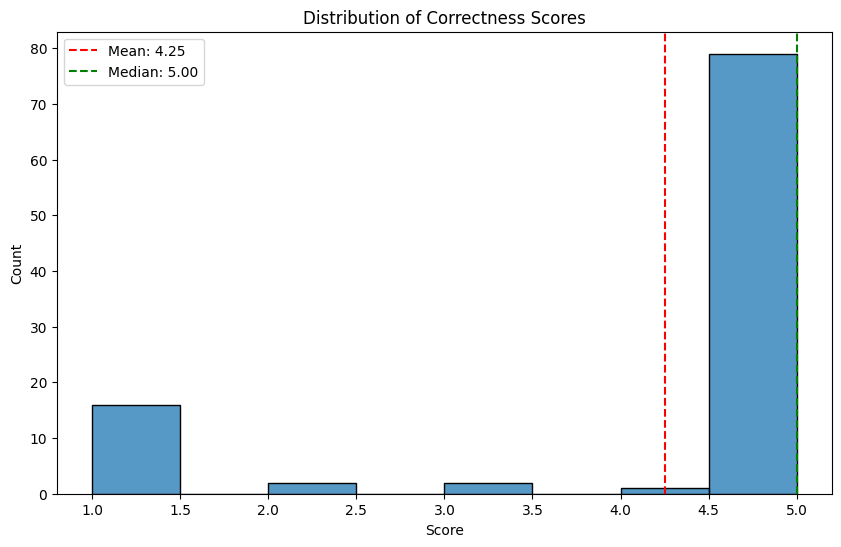

In [ ]:
plt.figure(figsize=(10, 6))

# Filtrar los datos por correctness y crear un distribution plot
correctness_data = detail[detail['evaluation_type'] == 'correctness']
sns.histplot(data=correctness_data, x='score', bins=8)

plt.title('Distribution of Correctness Scores')
plt.xlabel('Score')
plt.ylabel('Count')

# Agregar promedio y mediana
plt.axvline(
    correctness_data['score'].mean(),
    color='red',
    linestyle='--',
    label=f'Mean: {correctness_data['score'].mean():.2f}')
plt.axvline(
    correctness_data['score'].median(),
    color='green',
    linestyle='--',
    label=f'Median: {correctness_data["score"].median():.2f}')

plt.legend()
plt.show()

Podemos ver que unas 15 respuestas fueron malas, pero la gran mayoría son muy buenas.

> En definitiva, se construyó un sitema con un buen rendimiento general, con métricas que sugieren una buena capacidad de recuperación de información relevante y respuestas que en la mayoría de casos son completamente correctas, pero que tiene puntos de mejora.

<div style="
    background-color: rgb(0, 59, 117); 
    padding: 20px 0; 
    border: 2px solid rgb(0, 6, 67); 
    border-radius: 15px;
    text-align: center;
    line-height: 1.5;
    min-height: 50px;
    display: flex;
    align-items: center;
    justify-content: center;
">
    <h2 style="color: white; margin: 0;">🌐 <strong>Extra: Interfaz con Gradio</strong></h2>
</div>

In [28]:
import gradio as gr

In [36]:
def get_answer(message, history):
    return str(answer_question(message))

demo = gr.ChatInterface(
    fn=get_answer,
    type='messages',
    title='RAG QA Assistant',
    theme=gr.themes.Soft())

demo.launch(share=False)

* Running on local URL:  http://127.0.0.1:7861

To create a public link, set `share=True` in `launch()`.


In [37]:
demo.close()

Closing server running on port: 7861


<div style="
    background-color: rgb(0, 59, 117); 
    padding: 20px 0; 
    border: 2px solid rgb(0, 6, 67); 
    border-radius: 15px;
    text-align: center;
    line-height: 1.5;
    min-height: 50px;
    display: flex;
    align-items: center;
    justify-content: center;
">
    <h2 style="color: white; margin: 0;">🔗 <strong>Referencias</strong></h2>
</div>

**Docs**

- [Documentación oficial de *LlamaIndex*](https://docs.llamaindex.ai/en/stable/)
- [Ejemplos de uso de los principales componentes de LlamaIndex](https://docs.llamaindex.ai/en/stable/examples/)
- ¿Qué es RAG?:
    - [What is Retrieval-Augmented Generation (RAG) - YouTube?](https://www.youtube.com/watch?v=T-D1OfcDW1M&pp=ygUHaWJtIHJhZw%3D%3D)
    - [What is RAG (Retrieval-Augmented Generation) - AmazonAWS?](https://aws.amazon.com/what-is/retrieval-augmented-generation/)
- [Chroma](https://www.trychroma.com/)

**Recursos**

- [HotpotQA](https://hotpotqa.github.io/)
- [`sentence-transformers/multi-qa-MiniLM-L6-cos-v1`](https://huggingface.co/sentence-transformers/multi-qa-MiniLM-L6-cos-v1)
- [Tutorial - cómo evaluar un RAG en LlamaIndex](https://www.youtube.com/watch?v=l5z_Peocss0)